PyTorch 2.10.0+cu128 | device=cuda
Loading Books 5-core ...
  loaded 8,898,041 interactions in 34.5s
  users=603,668  items=367,982

[k-core] k=15  start: 8,898,041 interactions, 603,668 users, 367,982 items
[k-core] converged after 21 iter(s)
[k-core] k=15  after:  2,954,716 interactions, 68,497 users, 65,548 items, sparsity=99.9342%

Final graph: n_users=68,497  n_items=65,548  interactions=2,954,716
Split: train=2,817,722  val=68,497  test=68,497
After filtering eval users with no train history: val=68,497  test=68,497

A_hat sparse: shape=torch.Size([134045, 134045])  nnz=5,635,444

Running truncated SVD (q=5) ...
  done in 0.5s   U_hat=(68497, 5)  V_hat=(65548, 5)

LightGCL params: 8,578,880
E  1 * loss=1.9827  bpr=0.6907  cl=6.4598  R@20=0.0045  N@20=0.0016  64.2s
E  2 * loss=1.9505  bpr=0.6634  cl=6.4355  R@20=0.0093  N@20=0.0035  64.3s
E  3 * loss=1.7575  bpr=0.4433  cl=6.5710  R@20=0.0167  N@20=0.0065  64.1s
E  4 * loss=1.6200  bpr=0.2882  cl=6.6592  R@20=0.0212  N@20=0.0084  

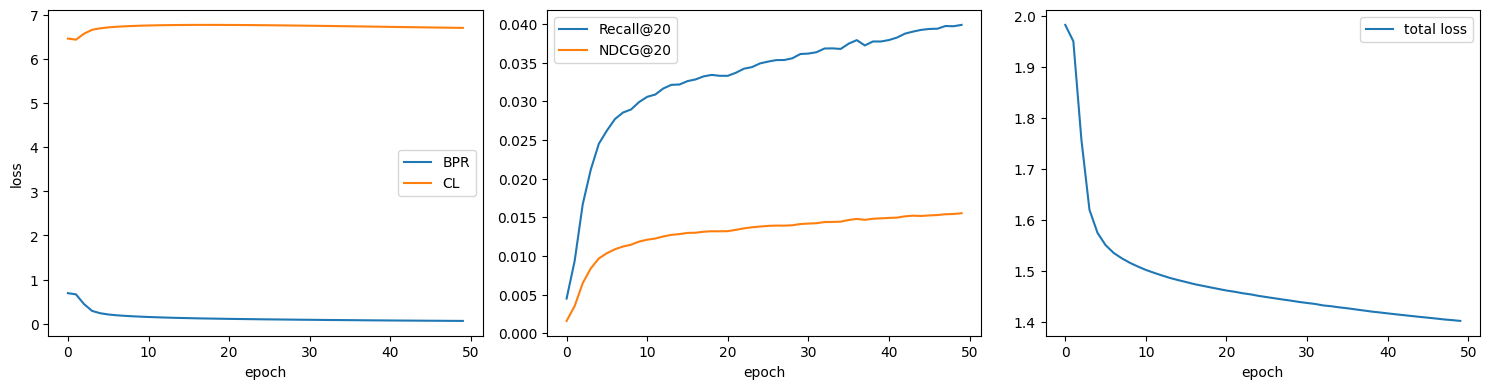

In [1]:

import os
import gzip
import json
import ast
import time
import math
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | device={device}")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

K_CORE = 15

def load_amazon_5core(path):
    """
    Load Amazon 5-core review file. Handles both `.json` and `.json.gz`.
    Records are one-per-line, sometimes JSON, sometimes Python dict literals
    — tolerate both like your teammate's loader does.
    Returns a (user_id, item_id, rating, timestamp) DataFrame.
    """
    opener = gzip.open if path.endswith('.gz') else open
    rows = []
    with opener(path, 'rt', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                try:
                    rec = ast.literal_eval(line)
                except Exception:
                    continue
            rows.append((
                rec['reviewerID'],
                rec['asin'],
                float(rec['overall']),
                int(rec['unixReviewTime']),
            ))
    df = pd.DataFrame(rows, columns=['user_id', 'item_id', 'rating', 'timestamp'])
    return df


BOOKS_PATH = 'reviews_Books_5.json/Books_5.json'

t0 = time.time()
ratings_df = load_amazon_5core(BOOKS_PATH)
print(f"  loaded {len(ratings_df):,} interactions in {time.time()-t0:.1f}s")
print(f"  users={ratings_df['user_id'].nunique():,}  items={ratings_df['item_id'].nunique():,}")



def filter_kcore(df, k, max_iter=50, verbose=True):
    """
    Iteratively keep users and items with >= k interactions until stable.
    Books at k=15 typically settles in <10 iterations.
    """
    if verbose:
        print(f"\n[k-core] k={k}  start: "
              f"{len(df):,} interactions, "
              f"{df['user_id'].nunique():,} users, "
              f"{df['item_id'].nunique():,} items")

    for it in range(max_iter):
        n_before = len(df)
        uc = df['user_id'].value_counts()
        ic = df['item_id'].value_counts()
        df = df[df['user_id'].isin(uc[uc >= k].index)
              & df['item_id'].isin(ic[ic >= k].index)]
        if len(df) == n_before:
            if verbose:
                print(f"[k-core] converged after {it+1} iter(s)")
            break
    else:
        if verbose:
            print(f"[k-core] hit max_iter={max_iter}, may not be fully converged")

    if verbose:
        sparsity = (1 - len(df) / (df['user_id'].nunique() * df['item_id'].nunique())) * 100
        print(f"[k-core] k={k}  after:  "
              f"{len(df):,} interactions, "
              f"{df['user_id'].nunique():,} users, "
              f"{df['item_id'].nunique():,} items, "
              f"sparsity={sparsity:.4f}%")
    return df



ratings_filtered = filter_kcore(ratings_df.copy(), k=K_CORE)



unique_users = ratings_filtered['user_id'].unique()
unique_items = ratings_filtered['item_id'].unique()
user2id = {u: i for i, u in enumerate(unique_users)}
item2id = {x: i for i, x in enumerate(unique_items)}
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user2id)
ratings_filtered['item_idx'] = ratings_filtered['item_id'].map(item2id)

n_users = len(user2id)
n_items = len(item2id)
print(f"\nFinal graph: n_users={n_users:,}  n_items={n_items:,}  "
      f"interactions={len(ratings_filtered):,}")


def temporal_split(df):
    """Last interaction per user -> test, second-last -> val, rest -> train."""
    df = df.sort_values('timestamp')
    test = df.groupby('user_idx').tail(1)
    rest = df[~df.index.isin(test.index)]
    val = rest.groupby('user_idx').tail(1)
    train = rest[~rest.index.isin(val.index)]
    return train, val, test


train_data, val_data, test_data = temporal_split(ratings_filtered)
print(f"Split: train={len(train_data):,}  val={len(val_data):,}  test={len(test_data):,}")


train_users = set(train_data['user_idx'].unique())
val_data = val_data[val_data['user_idx'].isin(train_users)]
test_data = test_data[test_data['user_idx'].isin(train_users)]
print(f"After filtering eval users with no train history: "
      f"val={len(val_data):,}  test={len(test_data):,}")




def build_R_sparse(train_df, n_users, n_items):
    """User-item interaction matrix R as scipy.sparse.csr (binary, implicit feedback)."""
    rows = train_df['user_idx'].values
    cols = train_df['item_idx'].values
    data = np.ones(len(rows), dtype=np.float32)
    R = sp.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))
    return R


def build_normalized_adj(R):

    
    n_u, n_i = R.shape
    # build A from R
    upper = sp.hstack([sp.csr_matrix((n_u, n_u), dtype=np.float32), R])
    lower = sp.hstack([R.T, sp.csr_matrix((n_i, n_i), dtype=np.float32)])
    A = sp.vstack([upper, lower]).tocoo()

    deg = np.array(A.sum(axis=1)).flatten()
    d_inv_sqrt = np.zeros_like(deg, dtype=np.float64)
    np.power(deg, -0.5, where=deg > 0, out=d_inv_sqrt)
    d_inv_sqrt[~np.isfinite(d_inv_sqrt)] = 0.0
    D_inv_sqrt = sp.diags(d_inv_sqrt)
    A_hat = (D_inv_sqrt @ A @ D_inv_sqrt).tocoo()

    idx = torch.from_numpy(np.vstack([A_hat.row, A_hat.col])).long()
    val = torch.from_numpy(A_hat.data).float()
    return torch.sparse_coo_tensor(idx, val, torch.Size(A_hat.shape)).coalesce().to(device)


def build_normalized_R(R):

    
    R = R.tocsr()
    du = np.array(R.sum(axis=1)).flatten()
    di = np.array(R.sum(axis=0)).flatten()
    du_inv = np.zeros_like(du, dtype=np.float64)
    di_inv = np.zeros_like(di, dtype=np.float64)
    np.power(du, -0.5, where=du > 0, out=du_inv)
    np.power(di, -0.5, where=di > 0, out=di_inv)
    du_inv[~np.isfinite(du_inv)] = 0
    di_inv[~np.isfinite(di_inv)] = 0
    R_norm = sp.diags(du_inv) @ R @ sp.diags(di_inv)
    return R_norm.tocoo()


R = build_R_sparse(train_data, n_users, n_items)
A_hat = build_normalized_adj(R)
R_norm_coo = build_normalized_R(R)
print(f"\nA_hat sparse: shape={A_hat.shape}  nnz={A_hat._nnz():,}")


def svd_lowrank_torch(R_norm_coo, q, niter=3):
    """
    GPU-friendly truncated SVD via torch.svd_lowrank on a sparse matrix.
    Returns U_hat = U * sqrt(S),  V_hat = V * sqrt(S)   so that U_hat @ V_hat.T ≈ R_norm.
    """
    idx = torch.from_numpy(np.vstack([R_norm_coo.row, R_norm_coo.col])).long()
    val = torch.from_numpy(R_norm_coo.data).float()
    R_t = torch.sparse_coo_tensor(idx, val, R_norm_coo.shape).coalesce().to(device)

    U, S, V = torch.svd_lowrank(R_t, q=q, niter=niter)
    sqrtS = torch.sqrt(S)
    U_hat = U * sqrtS.unsqueeze(0)
    V_hat = V * sqrtS.unsqueeze(0)
    return U_hat.detach(), V_hat.detach()


SVD_Q = 5      # paper default
print(f"\nRunning truncated SVD (q={SVD_Q}) ...")
t0 = time.time()
U_hat, V_hat = svd_lowrank_torch(R_norm_coo, q=SVD_Q, niter=3)
print(f"  done in {time.time()-t0:.1f}s   U_hat={tuple(U_hat.shape)}  V_hat={tuple(V_hat.shape)}")



class BPRDataset(Dataset):
    def __init__(self, train_df, n_items):
        self.users = train_df['user_idx'].values.astype(np.int64)
        self.pos = train_df['item_idx'].values.astype(np.int64)
        self.n_items = n_items
        self.user_pos = defaultdict(set)
        for u, i in zip(self.users, self.pos):
            self.user_pos[u].add(i)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = int(self.users[idx])
        p = int(self.pos[idx])
        while True:
            n = np.random.randint(self.n_items)
            if n not in self.user_pos[u]:
                return u, p, n


bpr_dataset = BPRDataset(train_data, n_items)
bpr_loader = DataLoader(bpr_dataset, batch_size=2048, shuffle=True,
                        num_workers=0, drop_last=False)





class LightGCL(nn.Module):
    def __init__(self, n_users, n_items, U_hat, V_hat,
                 d=64, n_layers=2, dropout=0.0):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.dropout = dropout

        self.E_u_0 = nn.Parameter(torch.empty(n_users, d))
        self.E_i_0 = nn.Parameter(torch.empty(n_items, d))
        nn.init.xavier_uniform_(self.E_u_0)
        nn.init.xavier_uniform_(self.E_i_0)

        # SVD view tensors are buffers — fixed during training
        self.register_buffer('U_hat', U_hat)
        self.register_buffer('V_hat', V_hat)

    def edge_drop(self, A_hat):
        """Edge dropout on the sparse adjacency. Off by default (paper found it optional)."""
        if self.dropout <= 0 or not self.training:
            return A_hat
        idx = A_hat._indices()
        val = A_hat._values()
        keep = torch.rand_like(val) > self.dropout
        idx = idx[:, keep]
        val = val[keep] / (1 - self.dropout)
        return torch.sparse_coo_tensor(idx, val, A_hat.shape).coalesce()

    def propagate(self, A_hat):

        
        A = self.edge_drop(A_hat)

        E_u_list = [self.E_u_0]
        E_i_list = [self.E_i_0]
        G_u_list = [self.E_u_0]   # layer-0 reuses input embeddings
        G_i_list = [self.E_i_0]

        for _ in range(self.n_layers):
            E_prev = torch.cat([E_u_list[-1], E_i_list[-1]], dim=0)
            E_next = torch.sparse.mm(A, E_prev)
            E_u_l, E_i_l = torch.split(E_next, [self.n_users, self.n_items], dim=0)
            E_u_list.append(E_u_l)
            E_i_list.append(E_i_l)

            # SVD-view propagation:
            #   G_u^{l+1} = U_hat (V_hat^T  E_i^l)
            #   G_i^{l+1} = V_hat (U_hat^T  E_u^l)
            G_u = self.U_hat @ (self.V_hat.t() @ E_i_list[-2])
            G_i = self.V_hat @ (self.U_hat.t() @ E_u_list[-2])
            G_u_list.append(G_u)
            G_i_list.append(G_i)

        # LightGCN-style aggregation: mean across layers
        E_u = torch.stack(E_u_list, dim=1).mean(dim=1)
        E_i = torch.stack(E_i_list, dim=1).mean(dim=1)
        return E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list

    def score(self, users, items, E_u, E_i):
        return (E_u[users] * E_i[items]).sum(dim=-1)


def info_nce(z1, z2, all_z2, tau):

    
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    all_z2 = F.normalize(all_z2, dim=-1)
    pos = (z1 * z2).sum(-1) / tau
    logits = z1 @ all_z2.t() / tau
    # log-sum-exp denominator
    return -(pos - torch.logsumexp(logits, dim=-1)).mean()


def lightgcl_loss(model, A_hat, users, pos, neg,
                  tau=0.5, lam_cl=0.2, lam_reg=1e-7):

    
    E_u, E_i, G_u_list, G_i_list, E_u_list, E_i_list = model.propagate(A_hat)

    # ---- BPR ----
    s_pos = model.score(users, pos, E_u, E_i)
    s_neg = model.score(users, neg, E_u, E_i)
    bpr = -F.logsigmoid(s_pos - s_neg).mean()

    # ---- Contrastive: per-layer alignment between main and SVD views ----
    u_uniq = torch.unique(users)
    i_uniq = torch.unique(torch.cat([pos, neg]))

    cl = 0.0
    for l in range(1, model.n_layers + 1):
        # users: align main-view E_u_l <-> SVD-view G_u_l
        cl = cl + info_nce(E_u_list[l][u_uniq], G_u_list[l][u_uniq],
                           E_u_list[l][u_uniq], tau)
        cl = cl + info_nce(G_u_list[l][u_uniq], E_u_list[l][u_uniq],
                           G_u_list[l][u_uniq], tau)
        # items: same idea
        cl = cl + info_nce(E_i_list[l][i_uniq], G_i_list[l][i_uniq],
                           E_i_list[l][i_uniq], tau)
        cl = cl + info_nce(G_i_list[l][i_uniq], E_i_list[l][i_uniq],
                           G_i_list[l][i_uniq], tau)
    cl = cl / (4 * model.n_layers)

    # ---- L2 reg on initial embeddings ----
    reg = (model.E_u_0[users].pow(2).sum()
         + model.E_i_0[pos].pow(2).sum()
         + model.E_i_0[neg].pow(2).sum()) / users.size(0)

    loss = bpr + lam_cl * cl + lam_reg * reg
    return loss, bpr.item(), cl.item() if torch.is_tensor(cl) else float(cl)


    
@torch.no_grad()
def evaluate(model, A_hat, train_df, eval_df, K=20, batch_size=512):
    model.eval()
    E_u, E_i, *_ = model.propagate(A_hat)

    train_mask = defaultdict(list)
    for u, i in zip(train_df['user_idx'].values, train_df['item_idx'].values):
        train_mask[int(u)].append(int(i))

    eval_users = eval_df['user_idx'].values.astype(np.int64)
    eval_items = eval_df['item_idx'].values.astype(np.int64)

    recalls, ndcgs = [], []
    for s in range(0, len(eval_users), batch_size):
        ub = eval_users[s:s+batch_size]
        tb = eval_items[s:s+batch_size]
        u_emb = E_u[torch.from_numpy(ub).to(device)]
        scores = u_emb @ E_i.t()
        for bi, u in enumerate(ub):
            if u in train_mask:
                scores[bi, train_mask[u]] = float('-inf')
        _, topk = scores.topk(K, dim=-1)
        topk = topk.cpu().numpy()
        for bi, target in enumerate(tb):
            hits = (topk[bi] == target)
            if hits.any():
                rank = int(hits.argmax())
                recalls.append(1.0)
                ndcgs.append(1.0 / np.log2(rank + 2))
            else:
                recalls.append(0.0)
                ndcgs.append(0.0)
    return float(np.mean(recalls)), float(np.mean(ndcgs))


    
def train_lightgcl(model, A_hat, loader, train_df, val_df,
                   n_epochs=50, lr=1e-3, tau=0.5, lam_cl=0.2, lam_reg=1e-7,
                   K=20, patience=5, ckpt='lightgcl_best.pt'):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'bpr': [], 'cl': [], 'val_recall': [], 'val_ndcg': []}
    best, no_improve = -1.0, 0

    for epoch in range(n_epochs):
        model.train()
        t0 = time.time()
        tot_loss = tot_bpr = tot_cl = 0.0
        n_batches = 0
        for u, p, n in loader:
            u, p, n = u.to(device), p.to(device), n.to(device)
            opt.zero_grad()
            loss, bpr_v, cl_v = lightgcl_loss(model, A_hat, u, p, n,
                                              tau=tau, lam_cl=lam_cl, lam_reg=lam_reg)
            loss.backward()
            opt.step()
            tot_loss += loss.item(); tot_bpr += bpr_v; tot_cl += cl_v; n_batches += 1

        avg_loss = tot_loss / n_batches
        avg_bpr = tot_bpr / n_batches
        avg_cl = tot_cl / n_batches

        recall, ndcg = evaluate(model, A_hat, train_df, val_df, K=K)
        elapsed = time.time() - t0

        history['loss'].append(avg_loss); history['bpr'].append(avg_bpr); history['cl'].append(avg_cl)
        history['val_recall'].append(recall); history['val_ndcg'].append(ndcg)

        improved = recall > best
        marker = '*' if improved else ' '
        print(f"E{epoch+1:3d} {marker} loss={avg_loss:.4f}  bpr={avg_bpr:.4f}  cl={avg_cl:.4f}  "
              f"R@{K}={recall:.4f}  N@{K}={ndcg:.4f}  {elapsed:.1f}s")

        if improved:
            best, no_improve = recall, 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1
            if no_improve >= patience:
                print("early stop")
                break
    return history


model = LightGCL(n_users, n_items, U_hat, V_hat,
                 d=64, n_layers=2, dropout=0.0).to(device)
print(f"\nLightGCL params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

history = train_lightgcl(
    model, A_hat, bpr_loader, train_data, val_data,
    n_epochs=50, lr=1e-3, tau=0.5, lam_cl=0.2, lam_reg=1e-7,
    K=20, patience=5,
)



model.load_state_dict(torch.load('lightgcl_best.pt'))
test_recall, test_ndcg = evaluate(model, A_hat, train_data, test_data, K=20)
print(f"\nTEST  R@20={test_recall:.4f}  N@20={test_ndcg:.4f}")




fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['bpr'], label='BPR')
axes[0].plot(history['cl'], label='CL')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[1].plot(history['val_recall'], label='Recall@20')
axes[1].plot(history['val_ndcg'], label='NDCG@20')
axes[1].set_xlabel('epoch'); axes[1].legend()
axes[2].plot(history['loss'], label='total loss')
axes[2].set_xlabel('epoch'); axes[2].legend()
plt.tight_layout()
plt.savefig('lightgcl_curves.png', dpi=120)
print("saved lightgcl_curves.png")